Import the standard libraries for arrays, dataframes, plotting, and visualization.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the Social Network Ads dataset and preview the first five rows.


In [26]:
df  = pd.read_csv("../../datasets/Social_Network_Ads.csv")
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Show dataframe structure and data types using df.info().


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


Show a random sample of rows from the dataset with df.sample().


In [28]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
237,15753874,Female,37,80000,0
76,15746737,Male,18,52000,0
377,15800215,Female,42,53000,0
140,15807909,Male,19,85000,0
282,15750447,Male,37,70000,1


Note that train-test split should happen before scaling in feature engineering.


In [29]:
#it is recommended to do the train test split process before doing standardisation and normalisation
# in feature engineering


Select feature columns X and the target column y from the dataframe.


In [30]:
x = df.iloc[:,2:4]#here x means all the input columns
y = df.iloc[:,-1]#here y means all the output columns , in this case it is purchased column

Split the data into training and test sets using train_test_split().


In [31]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)

Inspect the shape of the training feature set X_train.


In [32]:
X_train.shape

(280, 2)

Inspect the shape of the training labels Y_train.


In [33]:
Y_train.shape

(280,)

Create a StandardScaler, fit it on X_train, and learn mean and scale.


In [34]:
from sklearn.preprocessing import StandardScaler#importing the library
scaler = StandardScaler()#creating an object
scaler.fit(X_train)#fitting the X_train data so that it remember mean and sd


,copy,True
,with_mean,True
,with_std,True


Apply the fitted scaler to transform both training and test features.


In [37]:
X_train_transformed = scaler.transform(X_train)#transforming the X_train data
X_test_transformed = scaler.transform(X_test)#transforming the X_test data

Convert the scaled arrays back to pandas DataFrames with original columns.


Visualize the original feature scale before standardization.

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

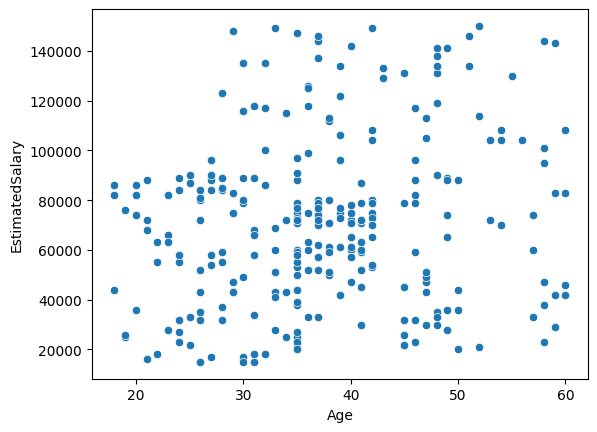

In [46]:
sns.scatterplot(
    x=X_train["Age"],
    y=X_train["EstimatedSalary"]
)

Convert the scaled arrays back into DataFrames with the original column names.

In [38]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns = X_train.columns)#converting them to dataframe
X_test_transformed = pd.DataFrame(X_test_transformed,columns = X_test.columns)#converting them to dataframe

Visualize the standardized feature scale after transformation.

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

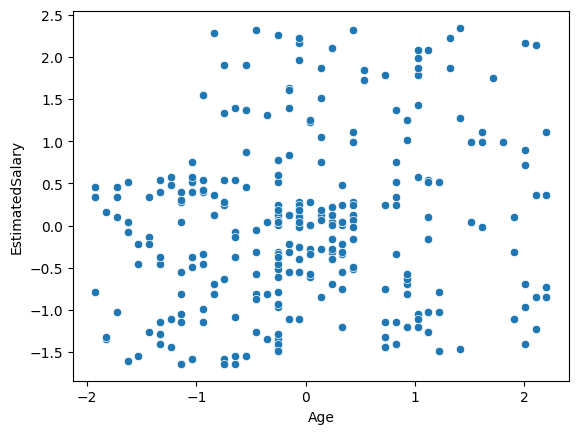

In [45]:
sns.scatterplot(
    x=X_train_transformed["Age"],
    y=X_train_transformed["EstimatedSalary"]
)

Display the scaled training features DataFrame.


In [39]:
X_train_transformed

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318
...,...,...
275,-1.333788,-1.286281
276,-1.137281,-1.050209
277,0.533024,1.841685
278,0.140011,0.189175


Display the scaled test features DataFrame.


In [40]:
X_test_transformed

,Age,EstimatedSalary
0,0.827784,-1.433827
1,2.105076,0.513775
2,-0.940775,-0.784626
3,1.024290,0.749848
4,-0.842522,-1.256772
...,...,...
115,-1.039028,-1.492845
116,-1.137281,-1.581373
117,-0.056496,0.661320
118,0.434771,-0.489535


Train logistic regression models on raw and standardized training data.


In [41]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_transformed = LogisticRegression()
lr.fit(X_train, Y_train)
lr_transformed.fit(X_train_transformed,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Generate predictions from both the raw-data and standardized-data models.

In [42]:
y_pred = lr.predict(X_test)#predicting the outcome
y_transformed_pred = lr_transformed.predict(X_test_transformed)#predicting the outcome

Import accuracy_score to compare model performance.

In [43]:
from sklearn.metrics import accuracy_score

Print both accuracy scores to measure the effect of standardization.

In [44]:
print("accuracy without standardisation is:", accuracy_score(Y_test,y_pred))
print("accuracy with standardisation is:", accuracy_score(Y_test,y_transformed_pred))

accuracy without standardisation is: 0.85
accuracy with standardisation is: 0.85
